In [1]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict 
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
import os
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from config.settings import (
    GROQ_API_KEY, GROQ_MODEL,
    LLM_TEMPERATURE, LLM_MAX_TOKENS,
    SYSTEM_PROMPT,
)
from models.rules_model.rules_extractor import extract_rules

e:\Rohanta_AI_workbook\campus_chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm = ChatGroq(
    model       = GROQ_MODEL,
    temperature = LLM_TEMPERATURE,
    max_tokens  = LLM_MAX_TOKENS,
    api_key     = GROQ_API_KEY,
)

In [6]:
class BotState(TypedDict):
    # ── Input ──────────────────────────────────────────────
    audio_query: str | None
    query:          str    

    audio_text_query : str   
    # ── Murge query ────────────────────────────────────────
    murge_query : str
    # ── After extract_node ─────────────────────────────────
    intent:         str        
    entities:       list[dict] 
    category_hints: list[str]  
    nav_pair:       dict | None  

    # ── After search_node ──────────────────────────────────
    kb_results:     list[dict] # matched KB entries
    kb_context:     str        # formatted text for LLM prompt
    is_list_mode:   bool       # True when returning all results for count/list queries

    # ── After llm_node ─────────────────────────────────────
    answer:         str        # final bot response

In [4]:
import whisper
model = whisper.load_model("base")

In [7]:
def audio_to_text(state:BotState):
    audio_query = state['audio_query']
    query = model.transcribe(audio_query)
    return {'audio_text_query': query['text']}

In [21]:
def text_input (state:BotState):
    query = state["query"]
    return {'query':query}

In [39]:
def merge_query(state: BotState):
    audio_text_query = state["audio_text_query"]
    query            = state["query"]

    if query and audio_text_query:
        merged = f"{query} {audio_text_query}".strip()
    elif query:
        merged = query
    else:
        merged = audio_text_query

    return {"merged_query": merged}

In [9]:
def intent_entity_extraction(state:BotState):
    query = state['murge_query']
    result = extract_rules("query")

    return {'intent': result['intent'],'entities': result['entities'],'category_hints':result['category_hints'],'nav_pair':result['nav_pair']}
    

In [10]:
from __future__ import annotations
import json
import re
from pathlib import Path
from rapidfuzz import fuzz
from config.settings import KB_PATH, KB_TOP_N, KB_SCORE_THRESHOLD, KB_NAV_THRESHOLD

# ---------------------------------------------------------------------------
# Load and index KB
# ---------------------------------------------------------------------------

def _load_kb(path: Path = KB_PATH) -> list[dict]:
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    for entry in data:
        entry["_search_text"] = " ".join(filter(None, [
            entry.get("name", ""),
            entry.get("description", ""),
            entry.get("category", ""),
            entry.get("map_reference", ""),
            entry.get("department", ""),
            entry.get("room_number", ""),
            entry.get("nearby_landmarks", ""),
        ])).lower()
    return data


_KB: list[dict] = _load_kb()

# ---------------------------------------------------------------------------
# List query detection
# ---------------------------------------------------------------------------
_LIST_PATTERNS = [
    r"\bhow many\b", r"\ball\b", r"\blist\b",
    r"\bcount\b",    r"\btotal\b", r"\bevery\b", r"\bshow all\b",
]

def is_list_query(query: str) -> bool:
    q = query.lower()
    return any(re.search(pat, q) for pat in _LIST_PATTERNS)

# ---------------------------------------------------------------------------
# Scoring
# ---------------------------------------------------------------------------

def _score_entry(entry: dict, query_lower: str,
                 entity_texts: list[str], category_hints: list[str]) -> float:
    score      = 0.0
    name_lower = entry.get("name", "").lower()
    st         = entry["_search_text"]

    if query_lower in name_lower or name_lower in query_lower:
        score += 80
    for ent in entity_texts:
        if ent.lower() in name_lower:   score += 60
        elif ent.lower() in st:         score += 20
    if entry.get("category") in category_hints:
        score += 40
    score += fuzz.token_set_ratio(query_lower, name_lower) * 0.3
    for word in re.findall(r"\w+", query_lower):
        if len(word) > 3 and word in st:
            score += 5

    return score

# ---------------------------------------------------------------------------
# Public search API
# ---------------------------------------------------------------------------

def search_by_category(category_hints: list[str]) -> list[dict]:
    """Return ALL KB entries matching any of the given categories."""
    return [e for e in _KB if e.get("category") in category_hints]


def search(extracted: dict,
           top_n: int = KB_TOP_N,
           score_threshold: float = KB_SCORE_THRESHOLD) -> list[dict]:
    """Scored search — returns top_n best matching KB entries."""
    query_lower    = extracted["raw_query"].lower()
    entity_texts   = [e["text"] for e in extracted.get("entities", [])]
    category_hints = extracted.get("category_hints", [])

    scored = []
    for entry in _KB:
        s = _score_entry(entry, query_lower, entity_texts, category_hints)
        if s >= score_threshold:
            scored.append({**entry, "_score": round(s, 2)})

    scored.sort(key=lambda x: x["_score"], reverse=True)
    return scored[:top_n]


def search_single(query_text: str, category_hints: list[str],
                  top_n: int = 1,
                  score_threshold: float = KB_NAV_THRESHOLD) -> list[dict]:
    """
    Search for a single location text (used in navigation node).
    Lower default threshold since location names are short.
    """
    extracted = {
        "raw_query":      query_text,
        "entities":       [],
        "category_hints": category_hints,
    }
    return search(extracted, top_n=top_n, score_threshold=score_threshold)


def smart_search(extracted: dict,
                 default_top_n: int = KB_TOP_N) -> tuple[list[dict], bool]:
    """
    Auto-detect list/count queries and switch to category-wide search.
    Returns (results, is_list_mode).
    """
    query          = extracted["raw_query"]
    category_hints = extracted.get("category_hints", [])

    if is_list_query(query) and category_hints:
        return search_by_category(category_hints), True

    return search(extracted, top_n=default_top_n), False

# ---------------------------------------------------------------------------
# Context formatter
# ---------------------------------------------------------------------------

def format_kb_context(results: list[dict], intent: str,
                      is_list_mode: bool = False) -> str:
    if not results:
        return "No matching locations found in the campus knowledge base."

    lines = []

    if is_list_mode:
        lines.append(f"Total found: {len(results)}\n")
        for i, r in enumerate(results, 1):
            line = f"{i}. {r['name']}"
            if r.get("map_reference"): line += f" — {r['map_reference']}"
            if r.get("department"):    line += f" ({r['department']})"
            lines.append(line)
    else:
        for i, r in enumerate(results, 1):
            lines.append(f"[Result {i}] {r['name']} (category: {r['category']})")
            lines.append(f"  Map reference : {r.get('map_reference', 'N/A')}")
            lines.append(f"  Description   : {r.get('description', 'N/A')}")
            lines.append(f"  Directions    : {r.get('directions_from_entrance', 'N/A')}")

            hours = r.get("opening_hours", {})
            if hours:
                hours_str = ", ".join(f"{d}: {h}" for d, h in hours.items())
                lines.append(f"  Opening hours : {hours_str}")

            events = r.get("events", [])
            if events:
                lines.append(f"  Events        : {'; '.join(events)}")

            if r.get("nearby_landmarks"):
                lines.append(f"  Nearby        : {r['nearby_landmarks']}")

            if r.get("directions_by_floor"):
                floor_str = " | ".join(f"{k}: {v}" for k, v in r["directions_by_floor"].items())
                lines.append(f"  By floor      : {floor_str}")

            lines.append("")

    return "\n".join(lines)


def location_summary(entry: dict) -> str:
    """Compact summary of a KB entry for navigation prompts."""
    parts = [entry.get("name", "Unknown")]
    if entry.get("floor") is not None:
        parts.append(f"Floor: {entry['floor']}")
    if entry.get("map_reference"):
        parts.append(f"Location: {entry['map_reference']}")
    if entry.get("directions_from_entrance"):
        parts.append("Directions from entrance: " + entry["directions_from_entrance"])
    if entry.get("nearby_landmarks"):
        parts.append("Nearby: " + entry["nearby_landmarks"])
    return "\n  ".join(parts)

In [11]:
CATEGORY_KEYWORDS: dict[str, list[str]] = {
    "library":             ["library", "books", "reading", "journal", "study"],
    "cafeteria":           ["cafeteria", "canteen", "food", "eat", "meal", "lunch", "dinner", "breakfast", "dining"],
    "gym":                 ["gym", "fitness", "sports", "yoga", "workout", "exercise", "basketball"],
    "it_lab":              ["it lab", "computer lab", "pc", "workstation", "programming lab"],
    "lecture_hall":        ["lecture hall", "auditorium", "hall", "lecture"],
    "student_union":       ["student union", "union", "lounge", "games room"],
    "admin_office":        ["admission", "registry", "enrollment", "transcript", "id card"],
    "career_center":       ["career", "job", "internship", "cv", "placement"],
    "medical_center":      ["medical", "health", "clinic", "doctor", "nurse", "pharmacy"],
    "department":          ["department", "dept"],
    "hod_office":          ["hod", "head of department"],
    "seminar_room":        ["seminar room", "seminar"],
    "classroom":           ["classroom", "class room"],
    "lab":                 ["lab", "laboratory"],
    "printing_room":       ["print", "photocopy", "xerox"],
    "security_office":     ["security", "guard"],
    "outdoor":             ["garden", "parking", "park", "outdoor"],
    "teachers_room":       ["teacher", "faculty", "staff room"],
    "engineering_college": ["engineering block", "engineering college", "engg"],
    "auditorium":          ["auditorium"],
}

def extract_category_hints(query: str) -> list[str]:
    q = query.lower()
    return [cat for cat, kws in CATEGORY_KEYWORDS.items() if any(kw in q for kw in kws)]

In [12]:
def kb_search(state: BotState):
    extracted = {
        "intent":         state["intent"],
        "entities":       state["entities"],
        "category_hints": state["category_hints"],
        "nav_pair":       state["nav_pair"],
        "raw_query":      state['murge_query'],
    }

    # ── Navigation: search source and destination separately ──
    if state["intent"] == "navigation" and state.get("nav_pair"):
        nav      = state["nav_pair"]
        src_text = nav["source"]
        dst_text = nav["destination"]

        src_r = search_single(src_text, extract_category_hints(src_text))
        dst_r = search_single(dst_text, extract_category_hints(dst_text))

        src_block = location_summary(src_r[0]) if src_r else f"'{src_text}' not found in KB"
        dst_block = location_summary(dst_r[0]) if dst_r else f"'{dst_text}' not found in KB"

        kb_context   = f"Starting location:\n  {src_block}\n\nDestination:\n  {dst_block}"
        kb_results   = (src_r or []) + (dst_r or [])
        is_list_mode = False

    # ── Regular / list query ──
    else:
        kb_results, is_list_mode = smart_search(extracted)
        kb_context = format_kb_context(kb_results, state["intent"], is_list_mode)

    return {
        **state,
        "kb_results":   kb_results,
        "kb_context":   kb_context,
        "is_list_mode": is_list_mode,
    }


In [13]:
def final_ans_generation(state: BotState):
    user_content = state['murge_query']
    messages     = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=user_content),
    ]
    response = llm.invoke(messages)
    answer   = response.content.strip()


    return {"answer":      answer}


In [40]:
graph = StateGraph(BotState)

graph.add_node("audio_to_text",audio_to_text)
graph.add_node("murge_query",murge_query)
graph.add_node('text_input',text_input)
graph.add_node("intent_entity_extraction",intent_entity_extraction)
graph.add_node("kb_search",kb_search)
graph.add_node("final_ans_generation",final_ans_generation)

graph.add_edge(START,'audio_to_text')
graph.add_edge(START,"text_input")
graph.add_edge("text_input","murge_query")
graph.add_edge('audio_to_text',"murge_query")
graph.add_edge("murge_query","intent_entity_extraction")
graph.add_edge("intent_entity_extraction","kb_search")
graph.add_edge("kb_search","final_ans_generation")
graph.add_edge("final_ans_generation",END)

workflow = graph.compile()

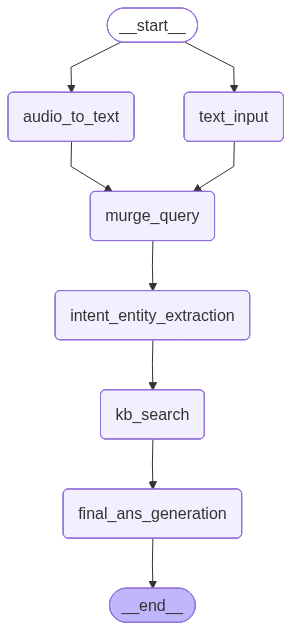

In [41]:
workflow

In [37]:
ans = workflow.invoke({'query': "Where is the library?",'audio_query':r'E:\Rohanta_AI_workbook\campus_chatbot\data\audio_samples\sample_0050.wav'})["answer"]

e:\Rohanta_AI_workbook\campus_chatbot\venv\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


In [38]:
print(ans)

The university library is located in the Main Academic Building (Building 1), on the 2nd floor. 

To get there, start from the main entrance, head straight down the hallway, and take the elevator to the 2nd floor. The library will be on your right.

The library's hours are as follows:
- Monday: 8:00 AM - 10:00 PM
- Tuesday: 8:00 AM - 10:00 PM
- Wednesday: 8:00 AM - 10:00 PM
- Thursday: 8:00 AM - 10:00 PM
- Friday: 8:00 AM - 6:00 PM
- Saturday: 10:00 AM - 6:00 PM
- Sunday: 12:00 PM - 10:00 PM

Available services include:
- Research assistance
- Printing and scanning
- Study rooms
- Group study areas
- Computers and laptops for use
- Access to online databases and journals

Workshops are held regularly, but the schedule varies. Check the library's website or the university's events calendar for the most up-to-date information.

Some upcoming workshops include:
- Research methods workshop: May 15th, 2:00 PM - 4:00 PM
- Citation management workshop: May 22nd, 3:00 PM - 5:00 PM
- Study skil